In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
save_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/tables")
save_dir.mkdir(parents=True, exist_ok=True)

In [5]:
def collect_wandb_run_dirs(
        sweep_dir,
        type_of_run: Literal['run', 'offline-run']='run'
    ):
    wandb_run_dirs = []
    for d in os.listdir(sweep_dir / "wandb"):
        if type_of_run in d:
            # print(d)
            wandb_run_dirs.append(sweep_dir / "wandb" / d)
    return wandb_run_dirs

In [6]:
def build_sweep_test_results_df(
        wandb_run_dirs,
        split: Literal['1-test-patch', '3-test-patch']='1-test-patch',
        conditioning=True
    ):
    wandb_run_dir_dfs = []
    for wandb_run_dir in wandb_run_dirs:
        if isinstance(wandb_run_dir, str):
            cfg = f"{wandb_run_dir}/files/user_specified_config.yaml"
            test_res_file = f"{wandb_run_dir}/files/results/test_metrics.csv"
        else:
            cfg = wandb_run_dir/"files"/"user_specified_config.yaml"
            test_res_file = wandb_run_dir/"files"/"results"/"test_metrics.csv"
        with open(cfg, 'r') as f:
            cfg = yaml.safe_load(f)
        test_results_df = pd.read_csv(test_res_file)
        
        test_results_df['dataset'] = cfg['dataset']['dataset_name']
        test_results_df['seed'] = cfg['experiment']['seed']
        if conditioning:
            test_results_df['model'] = cfg['model']['model_name']
        else:
            test_results_df['model'] = f"{cfg['model']['model_name']} w/o C"
        test_results_df['split'] = split

        wandb_run_dir_dfs.append(test_results_df)
        
    sweep_results = pd.concat(
        objs=wandb_run_dir_dfs,
        ignore_index=True
    )

    return sweep_results

In [7]:
def build_clean_sweep_results_df(
        df: pd.DataFrame,
        metrics: List[str] = [
            "pearson_1hop_nbr",
            "pearson_gene_wise_1hop_nbr",
            "mmd_1hop_nbr",
            "mmd_pca_1hop_nbr",
        ]
    ):
    # --- Step 1: groupby and transpose ---
    df_long = df.melt(
        id_vars=["dataset", "seed", "model", "split"], 
        var_name="metric", 
        value_name="value"
    )
    
    # --- Step 2: strip mode from metric name ---
    df_long["mode"] = df_long["metric"].str.extract(r"^(train|val|test)")
    df_long["metric"] = df_long["metric"].str.replace(r"^(train|val|test)_", "", regex=True)
    df_long = df_long[df_long['metric'].isin(metrics)]

    # --- Step 3: pretty names for metric ---
    metric_rename = {
        "pearson_1hop_nbr": "PC",
        "mmd_1hop_nbr": "MMD",
        "energy_pca_1hop_nbr": "E",
        "energy_1hop_nbr": "E1",
    }
    df_long["metric"] = df_long["metric"].map(metric_rename)

    # --- Step 4: pretty names for model ---
    model_rename = {
        "VQNiche": "SQUINT",
        "VQNiche w/o C": "SQUINT w/o C",
        "WFM": "WFM",
    }
    df_long["model"] = df_long["model"].map(model_rename)
    
    # --- Step 5: pretty names for dataset ---
    dataset_rename = {
        "xhs1000-39b_1p": "Skin (Human)",
        "mmb0-4b_1p": "Brain (Mouse)",
        "xhk1020-CV1-CV2-5b_1p": "Kidney (Human)",
    }
    df_long["dataset"] = df_long["dataset"].map(dataset_rename)
    
    # --- Step 6: pretty names for split ---
    split_rename = {
        "1-test-patch": "1 Patch",
        "3-test-patch": "3 Patches",
    }
    df_long["split"] = df_long["split"].map(split_rename)
    
    # --- Step 7: round to 4 decimals ---
    df_long['value'] = df_long['value'].round(4)
    
    df_long = df_long.drop_duplicates()
    
    return df_long

In [8]:
df_datasets = []
metrics = [
    "pearson_1hop_nbr",
    # "pearson_cell_wise",
    # "pearson_gene_wise_1hop_nbr",
    "mmd_1hop_nbr",
    # "mmd_pca_1hop_nbr",
    # "energy_pca_1hop_nbr",
    "energy_1hop_nbr",
]

# Dataset: mmb04-4b_1p

### Conditioning with RBF Distances + Batch-ID: Zero Masking

In [9]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20251125-132951")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Zero'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0310,NaN,0.895817,NaN,0.327599,0.104023,0.007678,0.021370,1.481152,mmb0-4b_1p,1,VQNiche,3-test-patch
1,0.0486,NaN,0.901328,NaN,0.327658,0.098384,0.007779,0.018374,1.629904,mmb0-4b_1p,0,VQNiche,3-test-patch
2,0.0362,NaN,0.898463,NaN,0.327624,0.107717,0.007730,0.023316,1.559148,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Brain (Mouse),1,SQUINT,3 Patches,PC,0.8958,test,Zero
9,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9013,test,Zero
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.8985,test,Zero
20,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.1040,test,Zero
21,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0984,test,Zero
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.1077,test,Zero
28,Brain (Mouse),1,SQUINT,3 Patches,E1,0.0214,test,Zero
29,Brain (Mouse),0,SQUINT,3 Patches,E1,0.0184,test,Zero
30,Brain (Mouse),2,SQUINT,3 Patches,E1,0.0233,test,Zero


### Conditioning with RBF Distances + Batch-ID: Learnable Masking

In [10]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20250918-120525")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Learnable'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0976,0.665215,0.906643,0.127004,0.309582,0.037895,0.00246,0.006198,19.380365,mmb0-4b_1p,0,VQNiche,3-test-patch
1,0.1256,0.664743,0.920757,0.126219,0.293255,0.039721,0.00246,0.004190,17.040207,mmb0-4b_1p,1,VQNiche,3-test-patch
2,0.1098,0.665079,0.920793,0.126838,0.298615,0.040766,0.00246,0.004737,18.873299,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9066,test,Learnable
9,Brain (Mouse),1,SQUINT,3 Patches,PC,0.9208,test,Learnable
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.9208,test,Learnable
20,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0379,test,Learnable
21,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.0397,test,Learnable
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.0408,test,Learnable
28,Brain (Mouse),0,SQUINT,3 Patches,E1,0.0062,test,Learnable
29,Brain (Mouse),1,SQUINT,3 Patches,E1,0.0042,test,Learnable
30,Brain (Mouse),2,SQUINT,3 Patches,E1,0.0047,test,Learnable


# Dataset: xhk1020-CV1-CV2-5b_1p

### Conditioning with RBF Distances + Batch-ID: Zero Masking

In [11]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20251130-180113")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Zero'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0254,NaN,0.858148,NaN,0.297931,0.043464,0.002041,0.002583,1.674115,xhk1020-CV1-CV2-5b_1p,0,VQNiche,3-test-patch
1,0.0280,NaN,0.863651,NaN,0.326194,0.039261,0.001998,0.001281,1.324014,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch
2,0.0280,NaN,0.863651,NaN,0.326194,0.039261,0.001998,0.001281,1.324014,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Kidney (Human),0,SQUINT,3 Patches,PC,0.8581,test,Zero
9,Kidney (Human),2,SQUINT,3 Patches,PC,0.8637,test,Zero
11,Kidney (Human),1,SQUINT,3 Patches,PC,0.8631,test,Zero
20,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0435,test,Zero
21,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0393,test,Zero
23,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0400,test,Zero
28,Kidney (Human),0,SQUINT,3 Patches,E1,0.0026,test,Zero
29,Kidney (Human),2,SQUINT,3 Patches,E1,0.0013,test,Zero
31,Kidney (Human),1,SQUINT,3 Patches,E1,0.0015,test,Zero


### Conditioning with RBF Distances + Batch-ID: Learnable Masking

In [12]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20250918-133207")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Learnable'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.024,0.508650,0.870048,0.058456,0.365251,0.018435,0.000848,0.002834,1.147923,xhk1020-CV1-CV2-5b_1p,0,VQNiche,3-test-patch
1,0.024,0.501943,0.867359,0.050387,0.366539,0.021097,0.000855,0.003627,1.193336,xhk1020-CV1-CV2-5b_1p,1,VQNiche,3-test-patch
2,0.025,0.497489,0.868739,0.054344,0.371600,0.018810,0.000851,0.002724,1.058001,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Kidney (Human),0,SQUINT,3 Patches,PC,0.8700,test,Learnable
9,Kidney (Human),1,SQUINT,3 Patches,PC,0.8674,test,Learnable
10,Kidney (Human),2,SQUINT,3 Patches,PC,0.8687,test,Learnable
20,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0184,test,Learnable
21,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0211,test,Learnable
22,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0188,test,Learnable
28,Kidney (Human),0,SQUINT,3 Patches,E1,0.0028,test,Learnable
29,Kidney (Human),1,SQUINT,3 Patches,E1,0.0036,test,Learnable
30,Kidney (Human),2,SQUINT,3 Patches,E1,0.0027,test,Learnable


# Dataset: xhs1000-39b_1p-oriented-7

### Conditioning with RBF Distances + Batch-ID: Zero Masking

In [13]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20251130-180113")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Zero'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.1104,NaN,0.793543,NaN,0.355620,0.116280,0.039199,0.004359,2.070449,xhs1000-39b_1p,1,VQNiche,3-test-patch
1,0.0990,NaN,0.789245,NaN,0.351929,0.116058,0.039813,0.003778,2.067285,xhs1000-39b_1p,0,VQNiche,3-test-patch
2,0.1134,NaN,0.789908,NaN,0.356551,0.115669,0.039213,0.003409,2.000555,xhs1000-39b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Skin (Human),1,SQUINT,3 Patches,PC,0.7935,test,Zero
9,Skin (Human),0,SQUINT,3 Patches,PC,0.7892,test,Zero
10,Skin (Human),2,SQUINT,3 Patches,PC,0.7899,test,Zero
20,Skin (Human),1,SQUINT,3 Patches,MMD,0.1163,test,Zero
21,Skin (Human),0,SQUINT,3 Patches,MMD,0.1161,test,Zero
22,Skin (Human),2,SQUINT,3 Patches,MMD,0.1157,test,Zero
28,Skin (Human),1,SQUINT,3 Patches,E1,0.0044,test,Zero
29,Skin (Human),0,SQUINT,3 Patches,E1,0.0038,test,Zero
30,Skin (Human),2,SQUINT,3 Patches,E1,0.0034,test,Zero


### Conditioning with RBF Distances + Batch-ID: Learnable Masking

In [14]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250923-220522")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Learnable'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
1,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
2,0.1198,0.437777,0.780558,0.130274,0.309842,0.091400,0.003610,0.012535,6.505773,4,xhs1000-39b_1p,0,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Skin (Human),2,SQUINT,3 Patches,PC,0.7847,test,Learnable
10,Skin (Human),0,SQUINT,3 Patches,PC,0.7806,test,Learnable
11,Skin (Human),1,SQUINT,3 Patches,PC,0.7994,test,Learnable
20,Skin (Human),2,SQUINT,3 Patches,MMD,0.0987,test,Learnable
22,Skin (Human),0,SQUINT,3 Patches,MMD,0.0914,test,Learnable
23,Skin (Human),1,SQUINT,3 Patches,MMD,0.0881,test,Learnable
28,Skin (Human),2,SQUINT,3 Patches,E1,0.0145,test,Learnable
30,Skin (Human),0,SQUINT,3 Patches,E1,0.0125,test,Learnable
31,Skin (Human),1,SQUINT,3 Patches,E1,0.0118,test,Learnable


# Results Dataframe

In [15]:
df_full = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
display(df_full.head(3))

,dataset,seed,model,split,metric,value,mode,Mask
0,Brain (Mouse),1,SQUINT,3 Patches,PC,0.8958,test,Zero
1,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9013,test,Zero
2,Brain (Mouse),2,SQUINT,3 Patches,PC,0.8985,test,Zero


In [16]:
df_avg = df_full.groupby(
        ['dataset', 'split', 'model', 'metric', 'Mask']
        )['value'].mean().reset_index()
df_avg = df_avg.round(4)
display(df_avg)

,dataset,split,model,metric,Mask,value
0,Brain (Mouse),3 Patches,SQUINT,E1,Learnable,0.0050
1,Brain (Mouse),3 Patches,SQUINT,E1,Zero,0.0210
2,Brain (Mouse),3 Patches,SQUINT,MMD,Learnable,0.0395
3,Brain (Mouse),3 Patches,SQUINT,MMD,Zero,0.1034
4,Brain (Mouse),3 Patches,SQUINT,PC,Learnable,0.9161
5,Brain (Mouse),3 Patches,SQUINT,PC,Zero,0.8985
6,Kidney (Human),3 Patches,SQUINT,E1,Learnable,0.0030
7,Kidney (Human),3 Patches,SQUINT,E1,Zero,0.0018
8,Kidney (Human),3 Patches,SQUINT,MMD,Learnable,0.0194
9,Kidney (Human),3 Patches,SQUINT,MMD,Zero,0.0409


# Plot

In [19]:
ablate = 'Mask'
metric = 'MMD'

In [116]:
df_metric = df_full[df_full['metric'] == metric]
datasets = df_metric['dataset'].unique().tolist()

print(datasets)

# datasets = [datasets[1], datasets[2], datasets[0]]
# datasets = datasets * 3
# datasets = datasets + [datasets[0]]
print(datasets)

masks = df_metric[ablate].unique().tolist()
print(masks)
masks = masks[1:]
print(masks)

['Brain (Mouse)', 'Kidney (Human)', 'Skin (Human)']
['Brain (Mouse)', 'Kidney (Human)', 'Skin (Human)']
['Zero', 'Learnable']
['Learnable']


In [117]:
df_metric

,dataset,seed,model,split,metric,value,mode,Mask
3,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.1040,test,Zero
4,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0984,test,Zero
5,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.1077,test,Zero
12,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0379,test,Learnable
13,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.0397,test,Learnable
14,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.0408,test,Learnable
21,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0435,test,Zero
22,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0393,test,Zero
23,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0400,test,Zero
30,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0184,test,Learnable


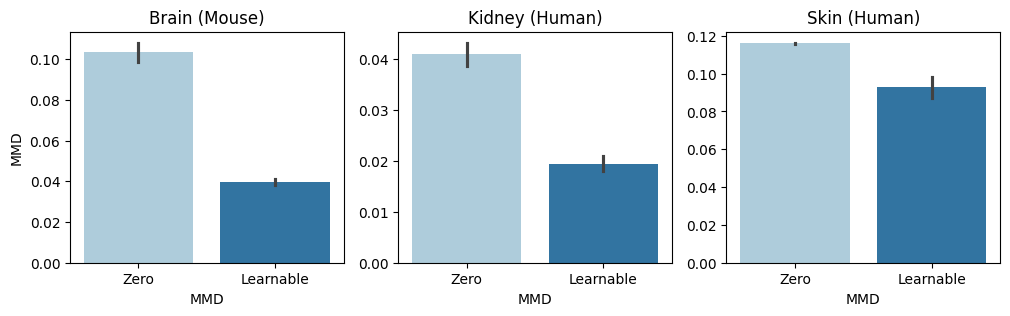

In [120]:
palette = sns.color_palette("Paired", 2)

# Create the plot
fig, axes = plt.subplots(1,3,figsize=(12,3))

for i, ax in enumerate(axes):
    df_dataset = df_metric[df_metric['dataset'] == datasets[i]]

    sns.barplot(
        data=df_dataset,
        x=ablate,
        y='value',
        hue=ablate,
        palette=palette,
        errorbar="sd",
        legend=False,
        ax=ax
    )

    # Customize the plot
    if i == 0:
        ax.set_ylabel(metric)
    else:
        ax.set_ylabel('')
    ax.set_xlabel(metric)
    ax.set_title(datasets[i])

# Show the plot
plt.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/ablations/mask_strategy.pdf", bbox_inches='tight')
# plt.show()

# Results Table

In [24]:
df_metric = df_full[df_full['metric'] == 'MMD']
grouped = df_metric.groupby(['dataset', ablate, 'split', 'model', 'metric'])['value'].agg(['mean', 'std']).reset_index()

# Combine mean and std dev into a single string
grouped['value'] = grouped.apply(lambda row: f"{row['mean']:.4f} $\\pm$ {row['std']:.4f}", axis=1)

display(grouped)

,dataset,Mask,split,model,metric,mean,std,value
0,Brain (Mouse),Learnable,3 Patches,SQUINT,MMD,0.039467,0.001464,0.0395 $\pm$ 0.0015
1,Brain (Mouse),Zero,3 Patches,SQUINT,MMD,0.103367,0.004682,0.1034 $\pm$ 0.0047
2,Kidney (Human),Learnable,3 Patches,SQUINT,MMD,0.019433,0.001457,0.0194 $\pm$ 0.0015
3,Kidney (Human),Zero,3 Patches,SQUINT,MMD,0.040933,0.002250,0.0409 $\pm$ 0.0023
4,Skin (Human),Learnable,3 Patches,SQUINT,MMD,0.092733,0.005424,0.0927 $\pm$ 0.0054
5,Skin (Human),Zero,3 Patches,SQUINT,MMD,0.116033,0.000306,0.1160 $\pm$ 0.0003


In [25]:
# create pivot table
pivot = grouped.pivot(
    index=ablate,
    columns='dataset',
    values='value'
)

# display as markdown
print(pivot.to_markdown())

| Mask      | Brain (Mouse)       | Kidney (Human)      | Skin (Human)        |
|:----------|:--------------------|:--------------------|:--------------------|
| Learnable | 0.0395 $\pm$ 0.0015 | 0.0194 $\pm$ 0.0015 | 0.0927 $\pm$ 0.0054 |
| Zero      | 0.1034 $\pm$ 0.0047 | 0.0409 $\pm$ 0.0023 | 0.1160 $\pm$ 0.0003 |


In [20]:
# choose one metric & model to display
subset = df_avg[(df_avg['metric'] == metric) & (df_avg['model'] == 'SQUINT')]

# create pivot table
pivot = subset.pivot_table(
    index=ablate,
    columns='dataset',
    values='value'
).round(4)

# display as markdown
print(pivot.to_markdown())

| Mask      |   Brain (Mouse) |   Kidney (Human) |   Skin (Human) |
|:----------|----------------:|-----------------:|---------------:|
| Learnable |          0.0395 |           0.0194 |         0.0927 |
| Zero      |          0.1034 |           0.0409 |         0.116  |
